# 3 — Read the results

Scoring a capture. **No cloud account required** if you are reading the
published `results/capture.json.gz`: it carries the oracle frozen into its
header, so the whole rubric runs locally.

This is the notebook to change if you disagree with how an answer is judged.
Capture and scoring are separate programs on purpose — `run_battery.py` records
what happened and never judges it, `src/scoring.py` judges and never re-runs an
agent. Editing the rubric costs a minute instead of a day.

`make report` is the non-interactive equivalent and writes
`results/report.md`. This notebook shows the same numbers with the charts.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path[:0] = [str(ROOT / "src"), str(ROOT / "examples")]

import battery
import plots
import report
import traces

import build_results

/home/user/git/vertex-ai-mlops/Applied ML/AI Agents/data-mcp-sandbox/.venv/lib/python3.11/site-packages/google/adk/features/_feature_decorator.py:71: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


## Which capture

The published one if it is present, otherwise your own sweep. The header is the
reproducibility block: it names the model, the temperature, the Toolbox version,
and — the field that decides whether the whole comparison means anything —
whether the per-tier service accounts were in force.

In [2]:
capture = traces.locate(ROOT / "results" / "capture.json.gz", battery.RESULTS_PATH)
cells = traces.load(capture)
meta = traces.read_header(capture)

print(f"{capture.relative_to(ROOT)}  -  {len(cells)} cells")
for field in ("agent_model", "temperature", "toolbox_version", "use_tier_sa",
              "runs", "git_commit", "started"):
    print(f"  {field:<16} {meta.get(field)}")

results/capture.json.gz  -  1200 cells
  agent_model      gemini-3.7-flash
  temperature      0.0
  toolbox_version  1.10.0
  use_tier_sa      True
  runs             5
  git_commit       834421c3
  started          2026-09-05T02:07:23+00:00


## Score it

`resolve_goldens` prefers goldens frozen into the capture. Falling back to live
BigQuery is right for whoever ran the sweep — the corpus anchors its timestamps
to build time, so a stored number rots as the sandbox ages — and impossible for
a reader, which is exactly why `make export` freezes them.

In [3]:
scores = build_results.score_all(cells, build_results.resolve_goldens(cells, meta))
print(f"scored {len(scores)} cells")

using goldens frozen into the capture (tiers 0, 1)


scored 1200 cells


## Headline

Cost per **correct answer**, not per cell: an arm that is cheap and wrong is not
cheap. The dollar and MiB columns stay empty here because BigQuery job
attribution needs a live `INFORMATION_SCHEMA` query — `make report` fills them
in. An unmeasured value prints `--`, never `0`.

In [4]:
print(report.headline(scores, costs={}))

| config | tier | accuracy (mean) | tokens / correct | MiB / correct | USD / correct | coverage |
|---|---|---|---|---|---|---|
| p1_managed | 0 | 37% | 1689323 | -- | -- | -- |
| p1_managed | 1 | 67% | 572233 | -- | -- | -- |
| p1_toolbox | 0 | 33% | 252921 | -- | -- | -- |
| p1_toolbox | 1 | 75% | 46428 | -- | -- | -- |
| p2_managed | 0 | 33% | 362823 | -- | -- | -- |
| p2_managed | 1 | 73% | 56688 | -- | -- | -- |
| p2_toolbox | 0 | 32% | 481595 | -- | -- | -- |
| p2_toolbox | 1 | 75% | 83898 | -- | -- | -- |
| p3_managed | 0 | 35% | 3159221 | -- | -- | -- |
| p3_managed | 1 | 75% | 626026 | -- | -- | -- |
| p3_toolbox | 0 | 33% | 583464 | -- | -- | -- |
| p3_toolbox | 1 | 75% | 124546 | -- | -- | -- |
| p1_matched | 0 | 35% | 344345 | -- | -- | -- |
| p1_matched | 1 | 67% | 96193 | -- | -- | -- |
| p3_matched | 0 | 35% | 777949 | -- | -- | -- |
| p3_matched | 1 | 75% | 117246 | -- | -- | -- |
| p4_bq_ca | 0 | 23% | 55464 | -- | -- | -- |
| p4_bq_ca | 1 | 75% | 8807 | -- | -- | -- |

## Does governance help?

The one chart to look at if you look at one. Same data, same model, same
questions on both bars of every pair — the only difference is whether the
warehouse was governed.

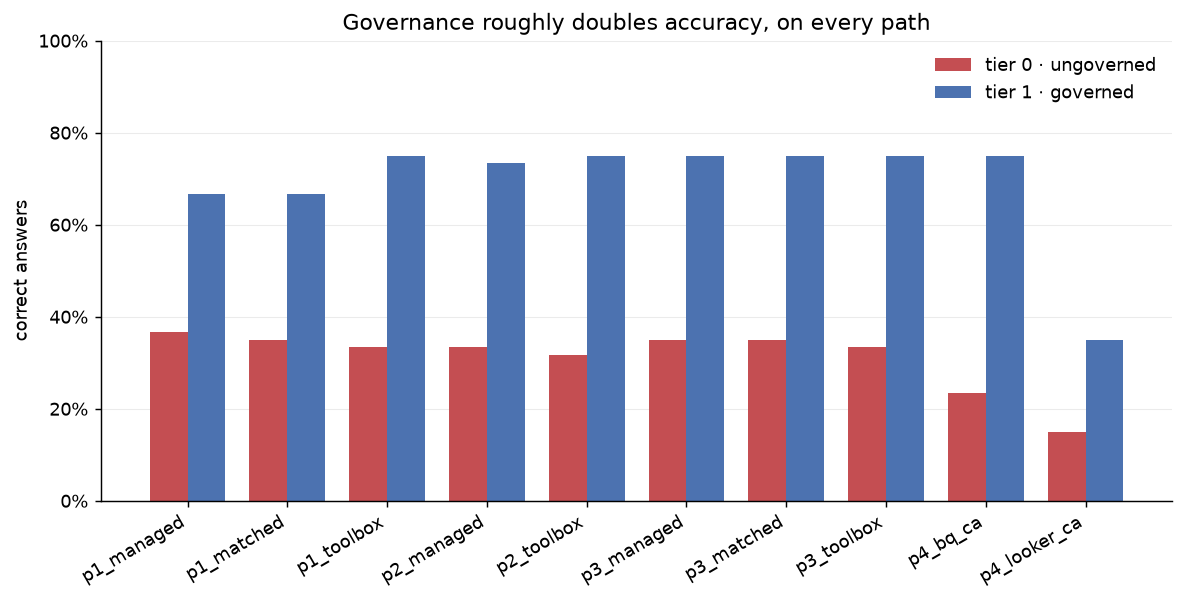

In [5]:
plots.accuracy_by_tier(scores)

## Is it enough?

No. Split the governed failures into *never acquired the rule* and *acquired it
and got the answer wrong anyway*. Acquisition is close to solved; application is
not, and that is the gap worth working on.

Path 4 is excluded rather than drawn as a zero bar: it discloses no query, so
there is no evidence to inspect. Ranking an arm bottom on a metric it was never
eligible for is a false finding, not a conservative one.

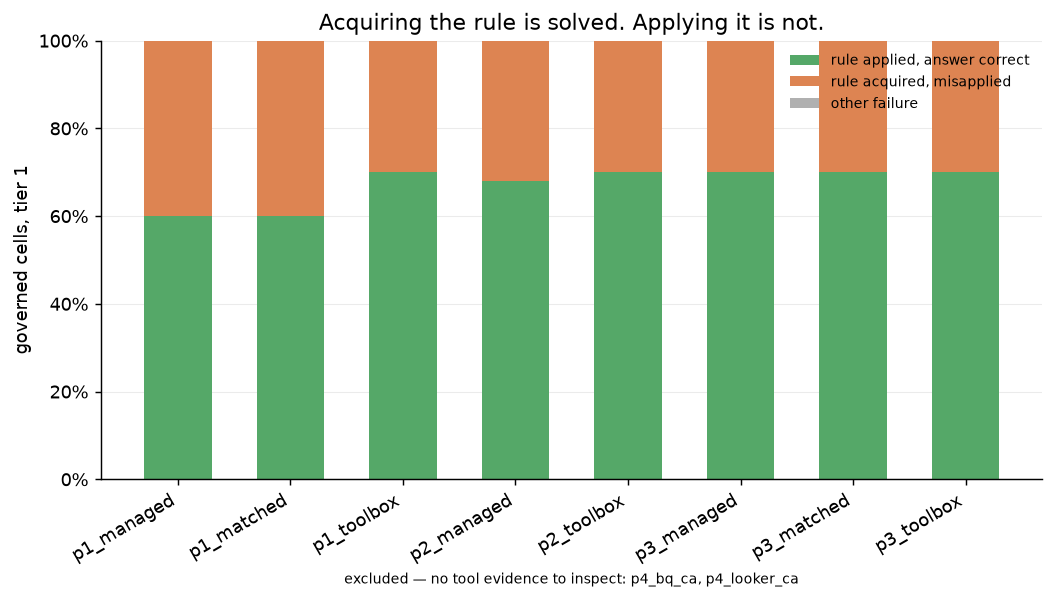

In [6]:
plots.acquisition_vs_application(scores)

## What does each arm cost?

Log x, because the arms span two orders of magnitude and that spread *is* the
finding — a linear axis collapses nine of them into one column.

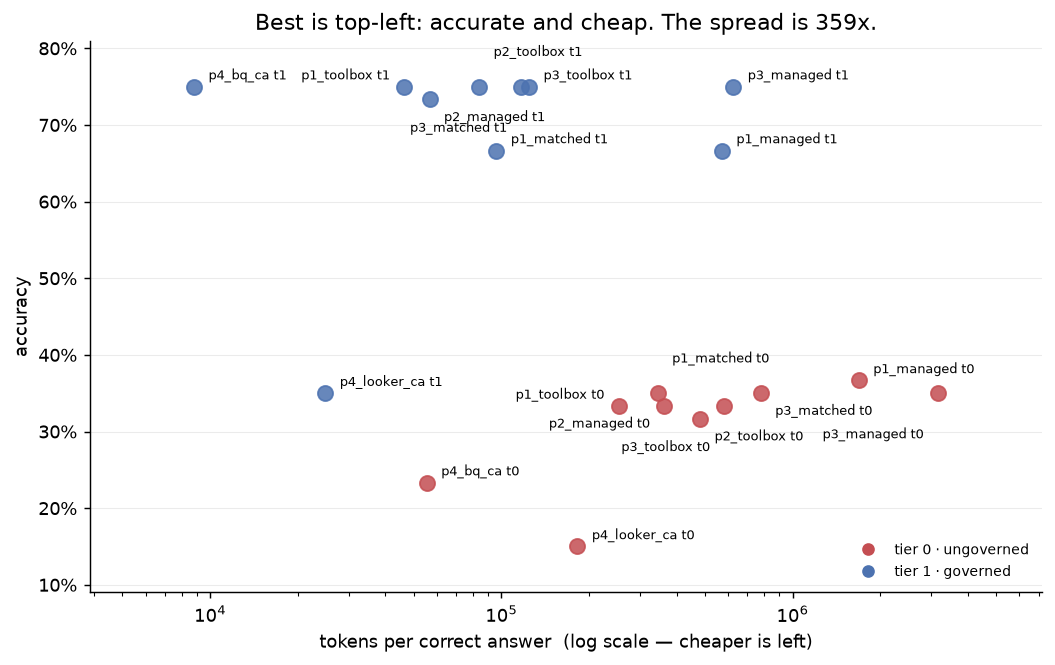

In [7]:
plots.cost_vs_accuracy(scores)

## Why does it cost that?

Tool declarations are re-sent to the model on **every turn**, so their
serialized size sets a floor under the whole conversation. Each capture measures
its own, at sweep time, into the header — because these are vendor schemas that
can change without notice, and this chart shows that detail dominating the cost
result. Tool *count* does not predict cost. Verbosity does. See
[`docs/paths.md`](../docs/paths.md).

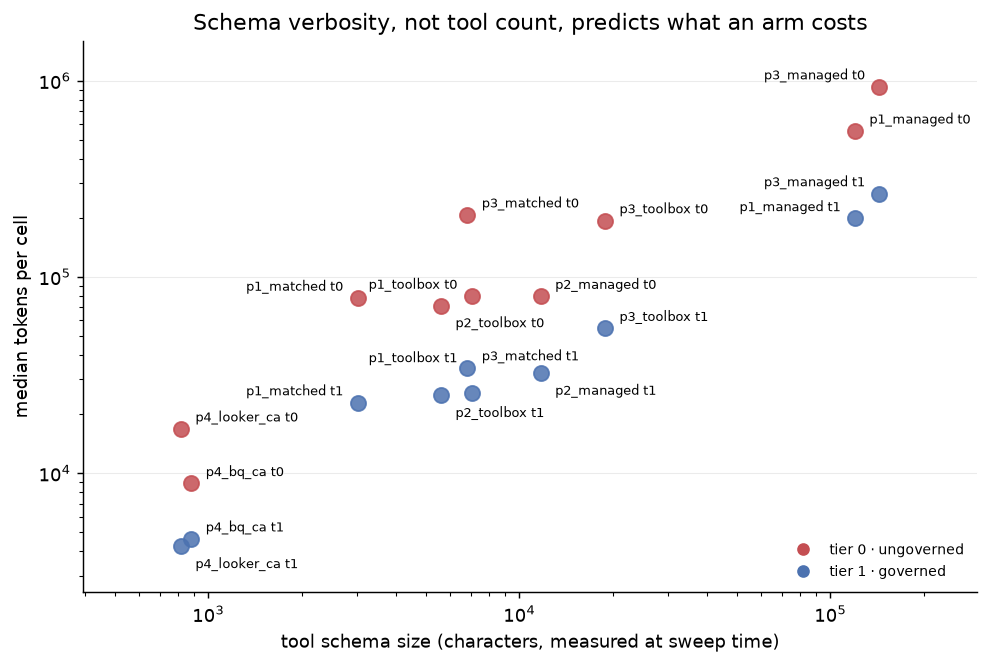

In [8]:
plots.schema_size_vs_cost(scores, meta.get("tool_schemas", {}))

## The tables behind the charts

In [9]:
for title, section in (
    ("Capture health", report.capture_health(scores)),
    ("Accuracy", report.accuracy(scores)),
    ("Acquisition vs application", report.acquisition(scores)),
    ("Evidence", report.evidence(scores)),
    ("Latency", report.latency(scores)),
):
    print(f"### {title}\n\n{section}\n")

### Capture health

| config | tier | attempted | scored | failed | quota-retried | CA leak |
|---|---|---|---|---|---|---|
| p1_managed | 0 | 60 | 60 | 0 | 8 | 0% |
| p1_managed | 1 | 60 | 60 | 0 | 1 | 0% |
| p1_toolbox | 0 | 60 | 60 | 0 | 5 | 57% |
| p1_toolbox | 1 | 60 | 60 | 0 | 4 | 32% |
| p2_managed | 0 | 60 | 60 | 0 | 5 | 0% |
| p2_managed | 1 | 60 | 60 | 0 | 4 | 0% |
| p2_toolbox | 0 | 60 | 60 | 0 | 4 | 0% |
| p2_toolbox | 1 | 60 | 60 | 0 | 0 | 0% |
| p3_managed | 0 | 60 | 60 | 0 | 8 | 0% |
| p3_managed | 1 | 60 | 60 | 0 | 2 | 0% |
| p3_toolbox | 0 | 60 | 60 | 0 | 2 | 65% |
| p3_toolbox | 1 | 60 | 60 | 0 | 0 | 30% |
| p1_matched | 0 | 60 | 60 | 0 | 1 | 0% |
| p1_matched | 1 | 60 | 60 | 0 | 1 | 0% |
| p3_matched | 0 | 60 | 60 | 0 | 10 | 0% |
| p3_matched | 1 | 60 | 60 | 0 | 14 | 0% |
| p4_bq_ca | 0 | 60 | 60 | 0 | 7 | 0% |
| p4_bq_ca | 1 | 60 | 60 | 0 | 0 | 0% |
| p4_looker_ca | 0 | 60 | 60 | 0 | 0 | 0% |
| p4_looker_ca | 1 | 60 | 60 | 0 | 0 | 0% |

### Accuracy

| config | tier

## Argue with the rubric

Every judgement above comes from `src/scoring.py`, which reads the raw capture
and nothing else. Change it, re-run this notebook, and see what moves.

Two passes are deliberately *not* run here, because each costs money:

```bash
make report                                     # + BigQuery cost attribution + LLM judge
uv run python examples/build_results.py --no-judge   # cost only
```

What these numbers will and will not reproduce on your own project:
[`docs/reproducing.md`](../docs/reproducing.md).